Num GPU Available: 0
Number of training batches: 1
Number of validation batches: 1


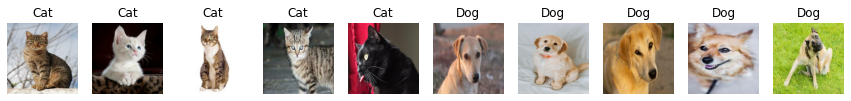

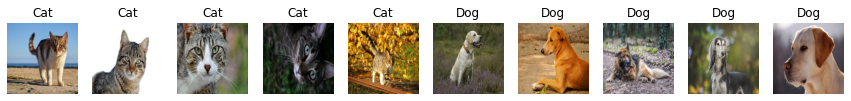

In [33]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import Xception
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import os
import matplotlib.pyplot as plt

print("Num GPU Available:", len(tf.config.list_physical_devices("GPU")))

IMG_SIZE=(150,150)
BATCH_SIZE=32

def preprocess_image(file_path):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_image(img,channels=3,expand_animations=False)
    img = tf.image.resize(img,IMG_SIZE)
    img =  tf.cast(img,tf.float32)/255.0
    return img
def create_dataset(directory):
    image_paths=[]
    labels=[]
    class_names=sorted(os.listdir(directory))
    for class_name in class_names:
        class_dir = os.path.join(directory,class_name)
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            image_paths.append(img_path)
            labels.append(class_names.index(class_name))

            
    def load_and_preprocess_image(img_path, label):
        return preprocess_image(img_path), label

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    dataset = dataset.map(
        load_and_preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)

    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

train_dir = "./image_train"
validation_dir = "./image_test"

train_dataset = create_dataset(train_dir)
validation_dataset = create_dataset(validation_dir)

print("Number of training batches:", len(train_dataset))
print("Number of validation batches:", len(validation_dataset))


def visualize_dataset(dataset, num_images=10):
    images, labels = next(iter(dataset))
    plt.figure(figsize=(15, 3))

    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(images[i])
        plt.title("Cat"if labels[i]==0 else "Dog")
        plt.axis("off")

    plt.show()
visualize_dataset(train_dataset)
visualize_dataset(validation_dataset)
